# Parallel Workflow: Batsman Stats

Three stats are calculated in parallel, then combined into a summary.

```
        -> calculate_sr       ->
START   -> calculate_bpb      ->  summary -> END
        -> calculate_boundary ->
```

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [3]:
# Parallel nodes return only the keys they change, not the whole state
def calculate_sr(state: BatsmanState):
    sr = state['runs'] / state['balls'] * 100
    return {'sr': round(sr, 2)}


def calculate_bpb(state: BatsmanState):
    bpb = state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb': round(bpb, 2)}


def calculate_boundary(state: BatsmanState):
    boundary_runs = state['fours'] * 4 + state['sixes'] * 6
    return {'boundary_percent': round(boundary_runs / state['runs'] * 100, 2)}


def summary(state: BatsmanState):
    text = (f"Strike rate: {state['sr']}\n"
            f"Balls per boundary: {state['bpb']}\n"
            f"Boundary percent: {state['boundary_percent']}")
    return {'summary': text}

In [4]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary', calculate_boundary)
graph.add_node('summary', summary)

# fan out: START goes to all three
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary')

# fan in: summary waits for all three
graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

In [5]:
result = workflow.invoke({'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4})
print(result['summary'])

Strike rate: 200.0
Balls per boundary: 5.0
Boundary percent: 48.0


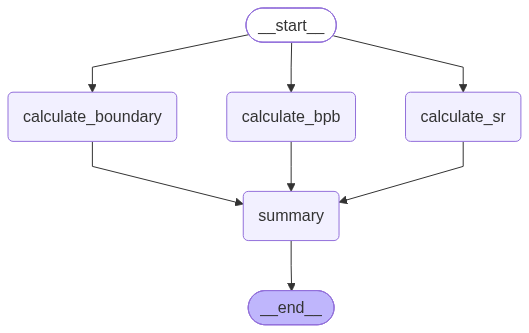

In [6]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())